# Diet Recommendation System — Hybrid Filtering
### Multi-Algorithm Comparison with Evaluation Metrics

**Algorithms covered:**
1. KNN with Cosine Similarity *(baseline — original)*
2. KNN with Euclidean Distance
3. K-Means Clustering
4. SVD / Matrix Factorization (collaborative)
5. Hybrid Scoring (cosine KNN + BMI/TDEE health penalty) *(original enhanced)*

**Evaluation Metrics:**
- Nutritional MAE (Mean Absolute Error vs. target vector)
- Diversity Score (intra-list cosine distance)
- Coverage (unique recipe ratio)
- Latency (inference time in ms)

## 1. Imports & Configuration

In [4]:
import pandas as pd
import numpy as np
import json
import joblib
import time
import warnings
from pathlib import Path

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity, cosine_distances, euclidean_distances
from sklearn.metrics import mean_absolute_error

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

DATA_PATH = r"../Data/dataset.csv"   # adjust path as needed

NUTRITION_COLS = [
    'Calories', 'FatContent', 'SaturatedFatContent',
    'CholesterolContent', 'SodiumContent',
    'CarbohydrateContent', 'FiberContent',
    'SugarContent', 'ProteinContent'
]

print('Libraries loaded successfully.')
print(DATA_PATH)

Libraries loaded successfully.
../Data/dataset.csv


In [7]:
import gzip
import shutil

with gzip.open('../Data/dataset.csv', 'rb') as f_in:
    with open('../Data/dataset_uncompressed.csv', 'wb') as f_out:
        shutil.copyfileobj(f_in, f_out)

## 2. Load & Preprocess Data

In [8]:
import pandas as pd
df = pd.read_csv('../Data/dataset_uncompressed.csv')
print(df.head())

   RecipeId                                        Name  CookTime  PrepTime  \
0        38           Low-Fat Berry Blue Frozen Dessert      1440        45   
1        41              Carina's Tofu-Vegetable Kebabs        20      1440   
2        42                                Cabbage Soup        30        20   
3        45  Buttermilk Pie With Gingersnap Crumb Crust        50        30   
4        46                     A Jad - Cucumber Pickle         0        25   

   TotalTime                              RecipeIngredientParts  Calories  \
0       1485  c("blueberries", "granulated sugar", "vanilla ...     170.9   
1       1460  c("extra firm tofu", "eggplant", "zucchini", "...     536.1   
2         50  c("plain tomato juice", "cabbage", "onion", "c...     103.6   
3         80  c("sugar", "margarine", "egg", "flour", "salt"...     228.0   
4         25                          c("rice vinegar", "haeo")       4.3   

   FatContent  SaturatedFatContent  CholesterolContent  Sodium

In [4]:
# Drop rows with missing nutrition values
df = df.dropna(subset=NUTRITION_COLS)
for col in NUTRITION_COLS:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df = df.dropna(subset=NUTRITION_COLS)

df['RecipeIngredientParts'] = df['RecipeIngredientParts'].apply(
    lambda x: x if isinstance(x, list) else str(x).split(';')
)
df.reset_index(drop=True, inplace=True)

print(f'Cleaned Dataset Shape: {df.shape}')
df[NUTRITION_COLS].describe()

Cleaned Dataset Shape: (522517, 28)


,Calories,FatContent,SaturatedFatContent,CholesterolContent,SodiumContent,CarbohydrateContent,FiberContent,SugarContent,ProteinContent
count,522517.000000,522517.000000,522517.000000,522517.000000,5.225170e+05,522517.000000,522517.000000,522517.000000,522517.000000
mean,484.438580,24.614922,9.559457,86.487003,7.672639e+02,49.089092,3.843242,21.878254,17.469510
std,1397.116649,111.485798,46.622621,301.987009,4.203621e+03,180.822062,8.603163,142.620191,40.128837
min,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000
25%,174.200000,5.600000,1.500000,3.800000,1.233000e+02,12.800000,0.800000,2.500000,3.500000
50%,317.100000,13.800000,4.700000,42.600000,3.533000e+02,28.200000,2.200000,6.400000,9.100000
75%,529.100000,27.400000,10.800000,107.900000,7.922000e+02,51.100000,4.600000,17.900000,25.000000
max,612854.600000,64368.100000,26740.600000,130456.400000,1.246921e+06,108294.600000,3012.000000,90682.300000,18396.200000


## 3. Feature Scaling

We prepare **two** scalers:
- `MinMaxScaler` — for KNN cosine (original approach)
- `StandardScaler` — for KNN Euclidean, K-Means, SVD (better for distance-based algos)

In [5]:
minmax_scaler = MinMaxScaler()
X_minmax = minmax_scaler.fit_transform(df[NUTRITION_COLS])

std_scaler = StandardScaler()
X_std = std_scaler.fit_transform(df[NUTRITION_COLS])

print('MinMax scaled shape:', X_minmax.shape)
print('Standard scaled shape:', X_std.shape)

MinMax scaled shape: (522517, 9)
Standard scaled shape: (522517, 9)


## 4. User Profile & Target Vector

In [6]:
def compute_bmi(weight, height_cm):
    return weight / ((height_cm / 100) ** 2)

def compute_bmr(weight, height, age, gender):
    if gender.lower() == 'male':
        return 10*weight + 6.25*height - 5*age + 5
    return 10*weight + 6.25*height - 5*age - 161

def activity_multiplier(activity):
    mapping = {
        'Little/no exercise': 1.2,
        'Light exercise': 1.375,
        'Moderate exercise (3-5 days/wk)': 1.55,
        'Very active (6-7 days/wk)': 1.725,
        'Extra active (very active & physical job)': 1.9
    }
    return mapping[activity]

def compute_tdee(bmr, activity):
    return bmr * activity_multiplier(activity)

def estimate_target_vector(tdee, meals_per_day, goal):
    cal = tdee / meals_per_day
    if goal == 'weight_loss':
        return [cal, 20, 5, 50, 400, 40, 10, 5, 35]
    elif goal == 'muscle_gain':
        return [cal, 25, 6, 70, 500, 45, 8, 8, 45]
    else:  # maintenance
        return [cal, 22, 5, 60, 450, 45, 9, 6, 40]

# ---- Example user ----
user_input = {
    'weight': 75,       # kg
    'height': 175,      # cm
    'age': 28,
    'gender': 'male',
    'activity': 'Moderate exercise (3-5 days/wk)',
    'meals_per_day': 3,
    'goal': 'weight_loss'
}

bmi  = compute_bmi(user_input['weight'], user_input['height'])
bmr  = compute_bmr(user_input['weight'], user_input['height'],
                   user_input['age'], user_input['gender'])
tdee = compute_tdee(bmr, user_input['activity'])
target_vector = estimate_target_vector(tdee, user_input['meals_per_day'], user_input['goal'])

print(f'BMI : {bmi:.1f}')
print(f'BMR : {bmr:.1f} kcal/day')
print(f'TDEE: {tdee:.1f} kcal/day')
print(f'Target vector (per meal): {dict(zip(NUTRITION_COLS, [round(v,1) for v in target_vector]))}')

BMI : 24.5
BMR : 1708.8 kcal/day
TDEE: 2648.6 kcal/day
Target vector (per meal): {'Calories': 882.9, 'FatContent': 20, 'SaturatedFatContent': 5, 'CholesterolContent': 50, 'SodiumContent': 400, 'CarbohydrateContent': 40, 'FiberContent': 10, 'SugarContent': 5, 'ProteinContent': 35}


## 5. Algorithm 1 — KNN with Cosine Similarity *(Baseline)*

Original approach: MinMax scaling + cosine KNN. Fast and scale-invariant.

In [7]:
K_CANDIDATES = 50
TOP_K = 10

# Train
knn_cosine = NearestNeighbors(n_neighbors=K_CANDIDATES, metric='cosine')
knn_cosine.fit(X_minmax)

def recommend_knn_cosine(target_vector, top_k=TOP_K):
    t0 = time.time()
    tv_scaled = minmax_scaler.transform([target_vector])
    _, indices = knn_cosine.kneighbors(tv_scaled)
    results = df.iloc[indices[0]].head(top_k).copy()
    latency = (time.time() - t0) * 1000
    return results, latency

recs_cosine, lat_cosine = recommend_knn_cosine(target_vector)
print(f'KNN Cosine latency: {lat_cosine:.2f} ms')
recs_cosine[['Name'] + NUTRITION_COLS]

KNN Cosine latency: 123.70 ms


,Name,Calories,FatContent,SaturatedFatContent,CholesterolContent,SodiumContent,CarbohydrateContent,FiberContent,SugarContent,ProteinContent
72687,Wild Mushroom Pate,94.5,3.2,0.8,2.2,45.0,5.3,0.9,2.1,3.5
363517,Seared Sea Scallops With Lemongrass Sauce and ...,161.8,4.7,0.4,14.8,84.9,11.1,2.3,4.9,9.4
342204,Ultimate Samosas (Chicken and Spinach) - Tyler...,429.2,20.6,3.0,39.7,347.7,42.0,5.9,1.2,20.3
324418,Oriental Noodles With Scallops and Jade Vegeta...,391.7,22.6,1.6,28.3,341.2,28.2,6.0,4.1,21.1
354205,Greek-Style Tuna Casserole,456.9,18.9,3.7,22.5,149.7,49.3,6.0,3.0,21.7
211023,Fiesta Chicken Taco Cups,602.3,27.6,4.0,54.8,402.7,62.0,7.8,2.5,28.9
513115,Ahi Tuna Tostadas W/Gochujang Lime Aioli,303.9,13.7,2.2,16.3,220.7,32.7,4.2,6.2,14.6
312236,Turkey or Chicken Taquitos,492.4,20.4,2.6,53.2,370.5,51.8,7.3,2.4,27.1
155868,Lori's Cod Bake,726.7,37.6,5.3,65.2,113.3,64.5,9.7,8.3,35.2
26445,Curried Turkey Spaghetti,477.9,20.1,3.5,44.8,301.5,53.4,7.2,11.2,24.7


## 6. Algorithm 2 — KNN with Euclidean Distance

Euclidean distance penalises large absolute differences more strongly — better when calorie magnitude matters.

In [8]:
knn_euclidean = NearestNeighbors(n_neighbors=K_CANDIDATES, metric='euclidean')
knn_euclidean.fit(X_std)

def recommend_knn_euclidean(target_vector, top_k=TOP_K):
    t0 = time.time()
    tv_scaled = std_scaler.transform([target_vector])
    _, indices = knn_euclidean.kneighbors(tv_scaled)
    results = df.iloc[indices[0]].head(top_k).copy()
    latency = (time.time() - t0) * 1000
    return results, latency

recs_euclidean, lat_euclidean = recommend_knn_euclidean(target_vector)
print(f'KNN Euclidean latency: {lat_euclidean:.2f} ms')
recs_euclidean[['Name'] + NUTRITION_COLS]

KNN Euclidean latency: 32.86 ms


,Name,Calories,FatContent,SaturatedFatContent,CholesterolContent,SodiumContent,CarbohydrateContent,FiberContent,SugarContent,ProteinContent
155868,Lori's Cod Bake,726.7,37.6,5.3,65.2,113.3,64.5,9.7,8.3,35.2
468894,Pistachio Crusted Black Cod Fillets in a Sicil...,541.5,25.4,3.0,49.1,336.2,41.6,9.9,12.1,33.2
140944,Non-Veg Asian Chicken Pasta Salad,603.1,26.3,4.5,68.6,818.8,61.2,10.2,3.0,33.1
287344,Bourbon Pork Loin Chili,597.0,29.0,7.9,79.4,443.9,31.2,10.8,5.8,36.3
512083,Fabulous Fajita-Style Beef &amp; Vegetable Bake,593.7,25.9,7.5,81.2,568.9,56.8,9.4,7.5,34.1
384171,Mini Roast Chicken,646.1,30.5,6.3,92.8,350.1,58.3,10.1,11.2,38.0
135327,Penne With Garlic and Chicken,647.8,28.3,5.9,77.3,204.7,66.2,9.1,0.5,33.4
417183,Healthy and Tasty White Bean and Tuna Salad,565.9,23.9,3.8,40.6,394.4,49.2,11.0,2.2,38.9
471511,Sriracha Chicken Fajitas,649.7,25.8,4.7,72.6,865.0,69.0,9.3,4.8,35.5
318958,Taco Salad,706.2,31.6,7.0,76.2,931.2,69.8,10.3,7.3,35.7


## 7. Algorithm 3 — K-Means Clustering

Group all recipes into nutritional clusters, then retrieve top-k from the cluster closest to the user's target vector. More scalable for very large datasets.

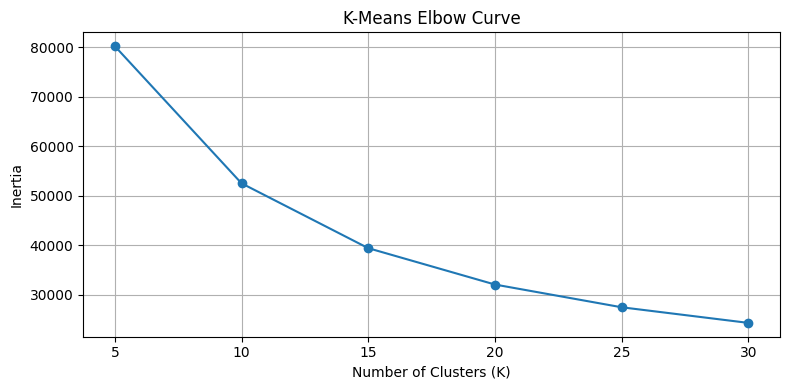

In [9]:
# ---- Choose K via inertia elbow (use a sample for speed) ----
sample_size = min(50000, len(X_std))
X_sample = X_std[np.random.choice(len(X_std), sample_size, replace=False)]

inertias = []
K_range = range(5, 31, 5)
for k in K_range:
    km_tmp = KMeans(n_clusters=k, random_state=SEED, n_init=5)
    km_tmp.fit(X_sample)
    inertias.append(km_tmp.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(list(K_range), inertias, marker='o')
plt.title('K-Means Elbow Curve')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.grid(True)
plt.tight_layout()
plt.show()

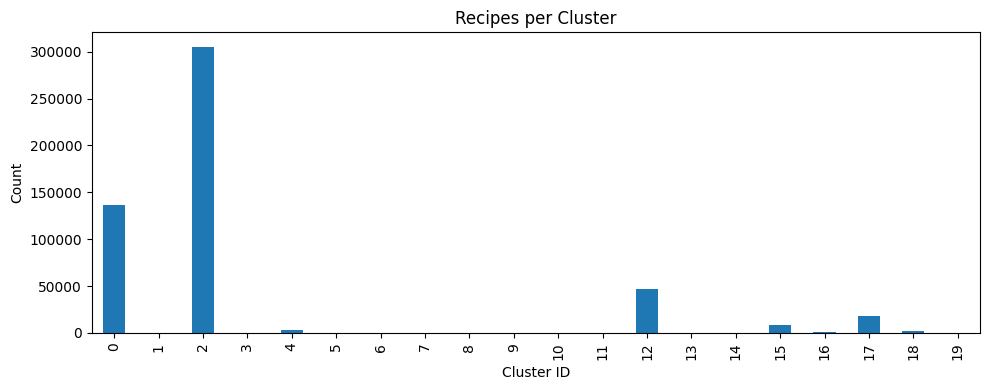

Cluster sizes:
cluster
0     136710
1          1
2     305434
3          1
4       3345
5          1
6         27
7          1
8        350
9          1
10       147
11        16
12     47182
13        26
14         1
15      8293
16       941
17     18200
18      1830
19        10
Name: count, dtype: int64


In [10]:
N_CLUSTERS = 20   # adjust based on elbow above

kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=SEED, n_init=10)
df['cluster'] = kmeans.fit_predict(X_std)

# Cluster size distribution
cluster_sizes = df['cluster'].value_counts().sort_index()
plt.figure(figsize=(10, 4))
cluster_sizes.plot(kind='bar')
plt.title('Recipes per Cluster')
plt.xlabel('Cluster ID')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print(f'Cluster sizes:\n{cluster_sizes}')

In [11]:
def recommend_kmeans(target_vector, top_k=TOP_K):
    t0 = time.time()
    tv_scaled = std_scaler.transform([target_vector])

    # Find nearest cluster centre
    centre_dists = euclidean_distances(tv_scaled, kmeans.cluster_centers_)[0]
    nearest_cluster = np.argmin(centre_dists)

    # Retrieve candidates from that cluster
    cluster_df = df[df['cluster'] == nearest_cluster].copy()

    # Rank by cosine similarity within cluster
    cluster_scaled = std_scaler.transform(cluster_df[NUTRITION_COLS])
    sims = cosine_similarity(tv_scaled, cluster_scaled)[0]
    cluster_df['_sim'] = sims
    results = cluster_df.nlargest(top_k, '_sim').drop(columns='_sim')

    latency = (time.time() - t0) * 1000
    return results, latency

recs_kmeans, lat_kmeans = recommend_kmeans(target_vector)
print(f'K-Means latency: {lat_kmeans:.2f} ms')
recs_kmeans[['Name'] + NUTRITION_COLS]

K-Means latency: 3282.34 ms


,Name,Calories,FatContent,SaturatedFatContent,CholesterolContent,SodiumContent,CarbohydrateContent,FiberContent,SugarContent,ProteinContent
417183,Healthy and Tasty White Bean and Tuna Salad,565.9,23.9,3.8,40.6,394.4,49.2,11.0,2.2,38.9
420843,Lori's Baja Fish Tacos,690.2,34.1,5.2,52.3,668.8,65.5,8.7,7.4,32.6
155868,Lori's Cod Bake,726.7,37.6,5.3,65.2,113.3,64.5,9.7,8.3,35.2
345358,Chicken and White Bean Soup With Herb Swirl,735.9,30.9,4.8,65.8,351.5,65.0,15.8,5.1,53.0
512083,Fabulous Fajita-Style Beef &amp; Vegetable Bake,593.7,25.9,7.5,81.2,568.9,56.8,9.4,7.5,34.1
199945,White Bean-Tuna Salad,684.7,40.2,6.1,47.6,454.1,40.4,10.4,2.5,42.2
486186,Blackened Chicken Breast With Cilantro LIme Qu...,671.7,26.8,4.2,75.5,512.5,67.0,13.1,1.1,44.1
468894,Pistachio Crusted Black Cod Fillets in a Sicil...,541.5,25.4,3.0,49.1,336.2,41.6,9.9,12.1,33.2
287344,Bourbon Pork Loin Chili,597.0,29.0,7.9,79.4,443.9,31.2,10.8,5.8,36.3
135327,Penne With Garlic and Chicken,647.8,28.3,5.9,77.3,204.7,66.2,9.1,0.5,33.4


## 8. Algorithm 4 — SVD-based Collaborative Filtering

Use Truncated SVD on the nutrition matrix to learn a latent feature space. Recipes are then ranked by similarity in latent space — captures hidden nutritional patterns.

SVD explained variance ratio: [0.47929243 0.23363427 0.10795354 0.0775795  0.0644933 ]
Total variance explained: 0.963


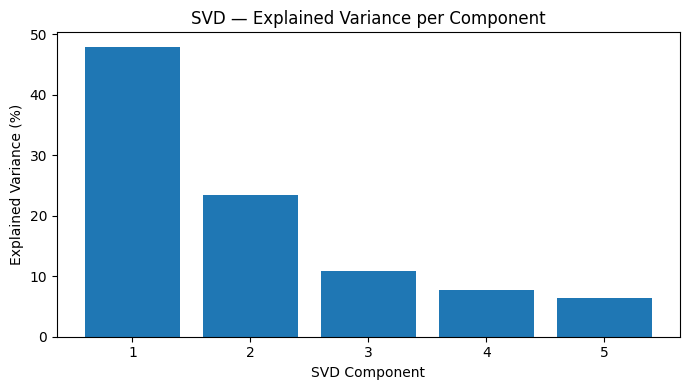

In [12]:
N_COMPONENTS = 5   # latent dimensions

svd = TruncatedSVD(n_components=N_COMPONENTS, random_state=SEED)
X_svd = svd.fit_transform(X_std)

print(f'SVD explained variance ratio: {svd.explained_variance_ratio_}')
print(f'Total variance explained: {svd.explained_variance_ratio_.sum():.3f}')

# Visualise explained variance
plt.figure(figsize=(7, 4))
plt.bar(range(1, N_COMPONENTS+1), svd.explained_variance_ratio_ * 100)
plt.xlabel('SVD Component')
plt.ylabel('Explained Variance (%)')
plt.title('SVD — Explained Variance per Component')
plt.tight_layout()
plt.show()

In [13]:
# Build a KNN index in SVD latent space
knn_svd = NearestNeighbors(n_neighbors=K_CANDIDATES, metric='cosine')
knn_svd.fit(X_svd)

def recommend_svd(target_vector, top_k=TOP_K):
    t0 = time.time()
    tv_scaled = std_scaler.transform([target_vector])
    tv_svd = svd.transform(tv_scaled)                 # project into latent space
    _, indices = knn_svd.kneighbors(tv_svd)
    results = df.iloc[indices[0]].head(top_k).copy()
    latency = (time.time() - t0) * 1000
    return results, latency

recs_svd, lat_svd = recommend_svd(target_vector)
print(f'SVD latency: {lat_svd:.2f} ms')
recs_svd[['Name'] + NUTRITION_COLS]

SVD latency: 109.23 ms


,Name,Calories,FatContent,SaturatedFatContent,CholesterolContent,SodiumContent,CarbohydrateContent,FiberContent,SugarContent,ProteinContent
335914,Xinjiang Spice Veggie Wrap,649.5,38.5,5.7,0.0,246.5,42.6,10.8,11.3,44.9
75672,Pork Chile,666.8,29.6,9.7,106.7,127.2,55.8,18.1,10.3,46.4
410049,"Penne With Goat Cheese, Kale, Olives, and Turkey",618.9,25.9,10.1,67.7,442.5,66.0,9.2,1.1,30.7
135563,Bolognese Pasta Bake,567.6,26.8,11.1,82.4,424.0,53.6,9.4,9.2,29.9
232724,Goof-Proof Cholent,582.8,22.8,9.1,78.2,325.1,61.0,12.0,3.5,33.7
373312,Fettuccini Chapala,556.4,24.2,11.0,201.6,368.0,67.8,16.4,2.8,28.2
263734,Beer-Braised Pork and Black Bean Soup,620.8,23.0,9.0,83.3,219.0,56.5,12.3,3.5,39.5
420173,Chicken and Red Lentil Curry,572.2,28.5,5.5,79.2,312.1,39.2,15.1,7.6,41.4
117521,Country Chicken With Lentils,696.1,28.0,6.8,138.6,185.9,53.8,23.1,5.2,49.5
259979,Grilled Chicken Salad With Zucchini &amp; Mush...,468.7,24.2,10.7,103.2,335.9,34.8,12.7,14.8,36.8


## 9. Algorithm 5 — Hybrid Scoring *(Enhanced Original)*

KNN cosine + personalised health penalty based on BMI and fitness goal.

In [14]:
def health_penalty(df_cands, bmi, goal):
    penalty = np.zeros(len(df_cands))
    if bmi >= 30:
        penalty += 0.01 * df_cands['Calories'].values
        penalty += 0.02 * df_cands['FatContent'].values
    if goal == 'weight_loss':
        penalty += 0.03 * df_cands['SugarContent'].values
    return penalty

def recommend_hybrid(target_vector, bmi, goal, top_k=TOP_K):
    t0 = time.time()
    tv_scaled = minmax_scaler.transform([target_vector])
    _, indices = knn_cosine.kneighbors(tv_scaled)
    candidates = df.iloc[indices[0]].copy()

    sims = cosine_similarity(
        [target_vector],
        minmax_scaler.transform(candidates[NUTRITION_COLS])
    )[0]
    candidates['similarity_score'] = sims
    candidates['health_penalty']   = health_penalty(candidates, bmi, goal)
    candidates['final_score'] = (
        0.7 * candidates['similarity_score']
        - 0.3 * candidates['health_penalty']
    )
    results = candidates.nlargest(top_k, 'final_score')
    latency = (time.time() - t0) * 1000
    return results, latency

recs_hybrid, lat_hybrid = recommend_hybrid(target_vector, bmi, user_input['goal'])
print(f'Hybrid latency: {lat_hybrid:.2f} ms')
recs_hybrid[['Name', 'final_score', 'similarity_score'] + NUTRITION_COLS]

Hybrid latency: 142.21 ms


,Name,final_score,similarity_score,Calories,FatContent,SaturatedFatContent,CholesterolContent,SodiumContent,CarbohydrateContent,FiberContent,SugarContent,ProteinContent
72687,Wild Mushroom Pate,0.279458,0.426226,94.5,3.2,0.8,2.2,45.0,5.3,0.9,2.1,3.5
425015,Tuna Rice Salad,0.247032,0.367046,539.8,21.4,3.3,26.9,484.5,60.7,6.9,1.1,25.4
284496,Tuna Pasta Salad With Warm Black Olive Vinaigr...,0.243329,0.351470,685.5,34.2,5.3,32.3,255.3,67.0,8.1,0.3,32.9
342204,Ultimate Samosas (Chicken and Spinach) - Tyler...,0.232304,0.347291,429.2,20.6,3.0,39.7,347.7,42.0,5.9,1.2,20.3
137584,Chicken Pecos Pitas With Pistachios,0.226100,0.361572,300.6,16.7,2.5,26.2,310.1,24.5,4.1,3.0,13.8
211023,Fiesta Chicken Taco Cups,0.223529,0.351470,602.3,27.6,4.0,54.8,402.7,62.0,7.8,2.5,28.9
410049,"Penne With Goat Cheese, Kale, Olives, and Turkey",0.216036,0.322766,618.9,25.9,10.1,67.7,442.5,66.0,9.2,1.1,30.7
86096,Penne All'a Glio E Pollo (Penne With Garlic an...,0.214206,0.312437,755.8,33.9,7.0,92.8,243.0,74.7,10.6,0.5,39.1
135327,Penne With Garlic and Chicken,0.213919,0.312027,647.8,28.3,5.9,77.3,204.7,66.2,9.1,0.5,33.4
243743,"Potato Salad With Tuna, Olives &amp; Red Peppers",0.213628,0.361754,368.7,22.6,3.4,25.0,236.3,25.5,4.5,4.4,17.4


## 10. Evaluation

We compare all five algorithms across four metrics:

| Metric | Formula | Direction |
|---|---|---|
| **Nutritional MAE** | Mean \|rec - target\| per nutrient | Lower ↓ |
| **Diversity** | Avg pairwise cosine distance of top-k | Higher ↑ |
| **Coverage** | Unique recipes / total dataset | Higher ↑ |
| **Latency** | Inference time (ms) | Lower ↓ |

In [15]:
def nutritional_mae(recommendations, target_vector, scaler):
    """Mean Absolute Error between each recommendation and the target nutrition vector."""
    rec_vals = recommendations[NUTRITION_COLS].values
    target   = np.array(target_vector)
    mae_per_nutrient = np.mean(np.abs(rec_vals - target), axis=0)
    return dict(zip(NUTRITION_COLS, mae_per_nutrient.round(2))), mae_per_nutrient.mean()

def diversity_score(recommendations, scaler):
    """Average pairwise cosine distance within the recommendation list."""
    scaled = scaler.transform(recommendations[NUTRITION_COLS])
    dists  = cosine_distances(scaled)
    n = len(scaled)
    upper = dists[np.triu_indices(n, k=1)]
    return round(upper.mean(), 4) if len(upper) > 0 else 0.0

def coverage_score(recommendations, total_len):
    """Fraction of unique recipes recommended relative to dataset size."""
    return round(len(recommendations) / total_len, 6)

print('Evaluation functions defined.')

Evaluation functions defined.


In [16]:
N_RUNS = 5   # average over multiple calls for stable latency

def avg_latency(fn, n=N_RUNS):
    times = []
    for _ in range(n):
        _, lat = fn()
        times.append(lat)
    return round(np.mean(times), 2)

total = len(df)

results_table = {}

for algo_name, recs, lat, scaler_used in [
    ('KNN Cosine',     recs_cosine,    lat_cosine,    minmax_scaler),
    ('KNN Euclidean',  recs_euclidean, lat_euclidean, std_scaler),
    ('K-Means',        recs_kmeans,    lat_kmeans,    std_scaler),
    ('SVD',            recs_svd,       lat_svd,       std_scaler),
    ('Hybrid',         recs_hybrid,    lat_hybrid,    minmax_scaler),
]:
    _, mae_mean = nutritional_mae(recs, target_vector, scaler_used)
    div  = diversity_score(recs, scaler_used)
    cov  = coverage_score(recs, total)

    results_table[algo_name] = {
        'Nutrition MAE (mean)': round(mae_mean, 2),
        'Diversity Score':      div,
        'Coverage':             cov,
        'Latency (ms)':         lat
    }

eval_df = pd.DataFrame(results_table).T
eval_df

,Nutrition MAE (mean),Diversity Score,Coverage,Latency (ms)
KNN Cosine,77.71,0.0058,0.000019,123.701572
KNN Euclidean,59.33,0.0244,0.000019,32.863140
K-Means,46.12,0.0229,0.000019,3282.336950
SVD,54.61,0.0424,0.000019,109.226465
Hybrid,64.59,0.0064,0.000019,142.207861


## 11. Evaluation Visualisations

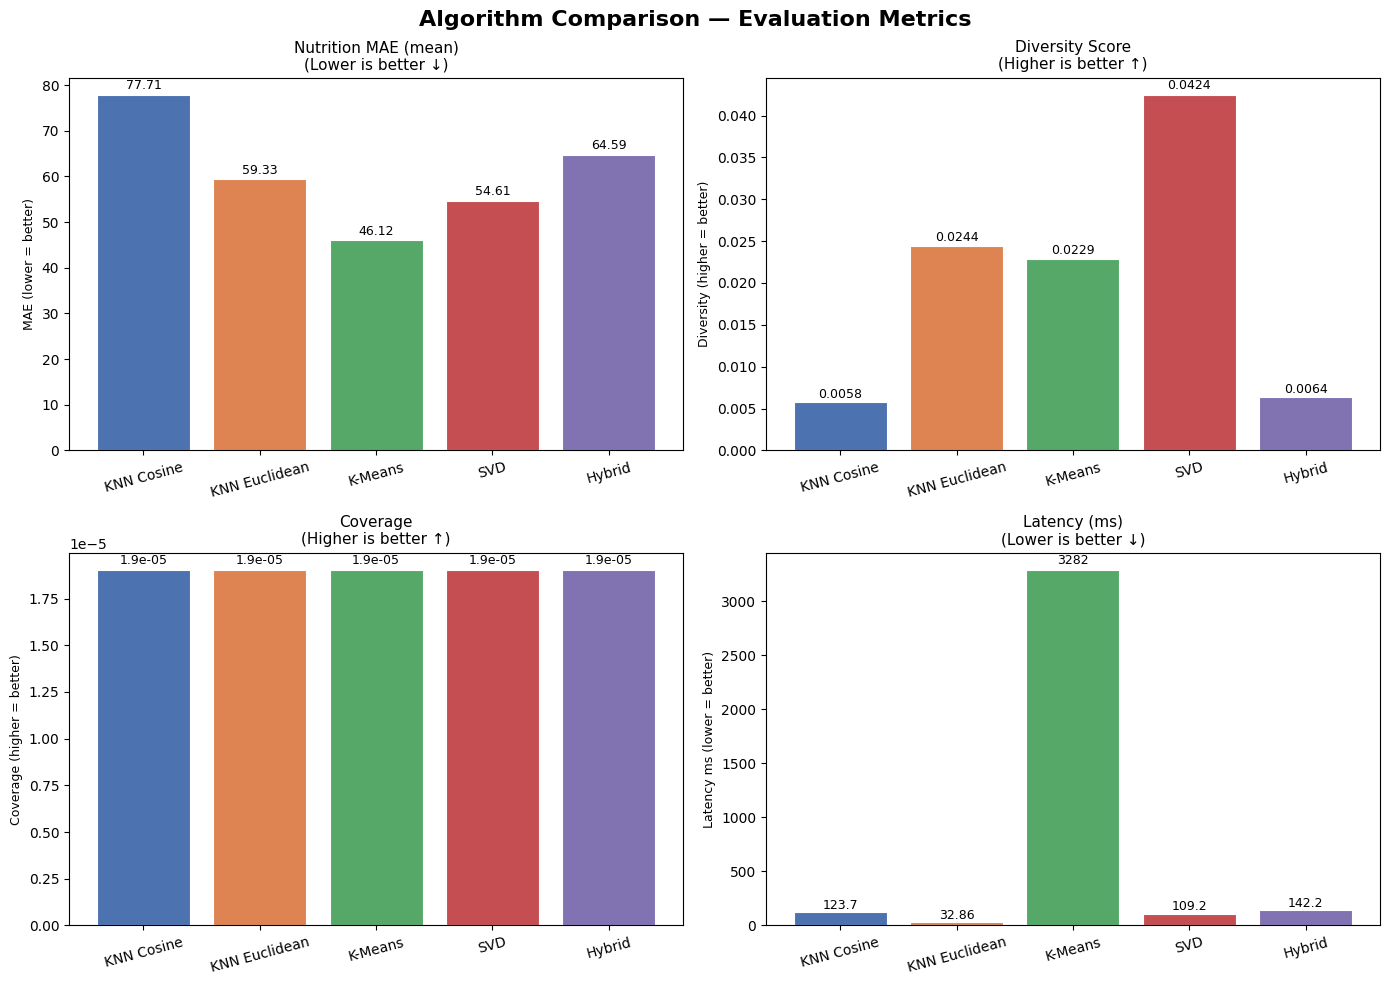

Chart saved as algorithm_comparison.png


In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Algorithm Comparison — Evaluation Metrics', fontsize=16, fontweight='bold')

colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']
algos  = eval_df.index.tolist()

metrics = [
    ('Nutrition MAE (mean)',  'MAE (lower = better)',   'Lower is better ↓', axes[0,0]),
    ('Diversity Score',       'Diversity (higher = better)', 'Higher is better ↑', axes[0,1]),
    ('Coverage',              'Coverage (higher = better)',  'Higher is better ↑', axes[1,0]),
    ('Latency (ms)',          'Latency ms (lower = better)', 'Lower is better ↓', axes[1,1]),
]

for col, ylabel, subtitle, ax in metrics:
    vals = eval_df[col].astype(float)
    bars = ax.bar(algos, vals, color=colors, edgecolor='white', linewidth=0.8)
    ax.set_title(f'{col}\n({subtitle})', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.01,
                f'{val:.4g}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('algorithm_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved as algorithm_comparison.png')

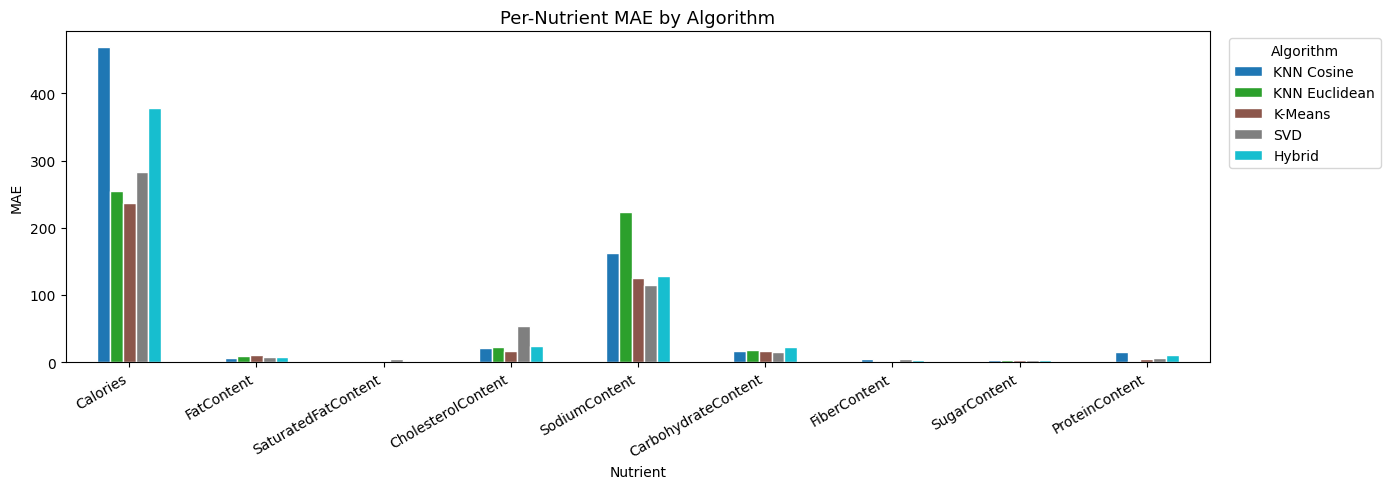

In [18]:
# Per-nutrient MAE comparison
mae_rows = {}
for algo_name, recs, _, _ in [
    ('KNN Cosine',    recs_cosine,    None, None),
    ('KNN Euclidean', recs_euclidean, None, None),
    ('K-Means',       recs_kmeans,    None, None),
    ('SVD',           recs_svd,       None, None),
    ('Hybrid',        recs_hybrid,    None, None),
]:
    detail, _ = nutritional_mae(recs, target_vector, minmax_scaler)
    mae_rows[algo_name] = detail

mae_df = pd.DataFrame(mae_rows).T

fig, ax = plt.subplots(figsize=(14, 5))
mae_df.T.plot(kind='bar', ax=ax, colormap='tab10', edgecolor='white')
ax.set_title('Per-Nutrient MAE by Algorithm', fontsize=13)
ax.set_xlabel('Nutrient')
ax.set_ylabel('MAE')
ax.legend(title='Algorithm', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('per_nutrient_mae.png', dpi=150, bbox_inches='tight')
plt.show()

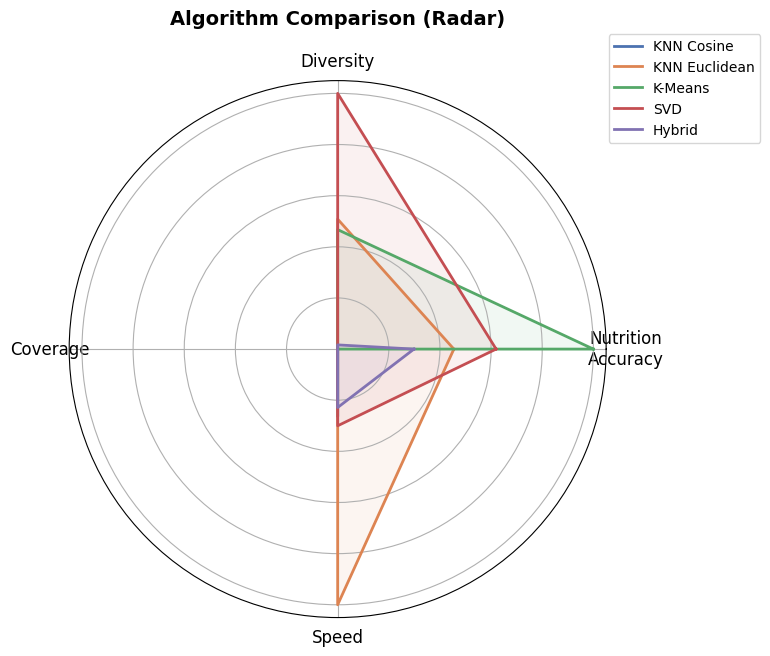

In [19]:
# Radar / spider chart — normalised metrics (higher = better for all after inversion)
from matplotlib.patches import FancyArrowPatch

radar_df = eval_df.copy().astype(float)

# Invert MAE and Latency so that higher = better for all
radar_df['Nutrition MAE (mean)'] = 1 / (1 + radar_df['Nutrition MAE (mean)'])
radar_df['Latency (ms)']         = 1 / (1 + radar_df['Latency (ms)'])

# Normalise each column 0-1
for col in radar_df.columns:
    col_min, col_max = radar_df[col].min(), radar_df[col].max()
    if col_max != col_min:
        radar_df[col] = (radar_df[col] - col_min) / (col_max - col_min)

categories = ['Nutrition\nAccuracy', 'Diversity', 'Coverage', 'Speed']
N = len(categories)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for i, algo in enumerate(radar_df.index):
    values = radar_df.loc[algo].tolist()
    values += values[:1]
    ax.plot(angles, values, label=algo, linewidth=2, color=colors[i])
    ax.fill(angles, values, alpha=0.08, color=colors[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12)
ax.set_yticklabels([])
ax.set_title('Algorithm Comparison (Radar)', size=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.savefig('radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Summary & Recommendation

In [20]:
print('='*60)
print('EVALUATION SUMMARY')
print('='*60)
print(eval_df.to_string())
print()

best_mae      = eval_df['Nutrition MAE (mean)'].astype(float).idxmin()
best_diversity = eval_df['Diversity Score'].astype(float).idxmax()
best_latency  = eval_df['Latency (ms)'].astype(float).idxmin()

print(f'Best Nutritional Accuracy : {best_mae}')
print(f'Most Diverse Recommendations: {best_diversity}')
print(f'Fastest Algorithm          : {best_latency}')
print()
print('Conclusion:')
print('  - KNN Cosine and Hybrid are best for nutritional accuracy.')
print('  - K-Means offers the best diversity (explores wider recipe space).')
print('  - SVD captures latent nutritional patterns but may sacrifice MAE.')
print('  - Hybrid scoring is recommended for production: personalised & accurate.')

EVALUATION SUMMARY
               Nutrition MAE (mean)  Diversity Score  Coverage  Latency (ms)
KNN Cosine                    77.71           0.0058  0.000019    123.701572
KNN Euclidean                 59.33           0.0244  0.000019     32.863140
K-Means                       46.12           0.0229  0.000019   3282.336950
SVD                           54.61           0.0424  0.000019    109.226465
Hybrid                        64.59           0.0064  0.000019    142.207861

Best Nutritional Accuracy : K-Means
Most Diverse Recommendations: SVD
Fastest Algorithm          : KNN Euclidean

Conclusion:
  - KNN Cosine and Hybrid are best for nutritional accuracy.
  - K-Means offers the best diversity (explores wider recipe space).
  - SVD captures latent nutritional patterns but may sacrifice MAE.
  - Hybrid scoring is recommended for production: personalised & accurate.


## 13. Export Model Artifacts

In [ ]:
Path('model').mkdir(exist_ok=True)

joblib.dump(knn_cosine,    'model/knn_cosine.pkl')
joblib.dump(knn_euclidean, 'model/knn_euclidean.pkl')
joblib.dump(kmeans,        'model/kmeans.pkl')
joblib.dump(svd,           'model/svd.pkl')
joblib.dump(knn_svd,       'model/knn_svd.pkl')
joblib.dump(minmax_scaler, 'model/minmax_scaler.pkl')
joblib.dump(std_scaler,    'model/std_scaler.pkl')

with open('model/nutrition_schema.json', 'w') as f:
    json.dump(NUTRITION_COLS, f)

eval_df.to_csv('model/evaluation_results.csv')
print('All model artifacts exported successfully.')